# Examples

This is a set of instructions that allow the user to run their own evolutionary models based on the conditions they select.

The first option is the default option where the user can select the mass, size (density), metallicity and galactocentric distance of the cluster. The default options are: solar metallicity Zsolar=0.02, metallicity Z=0.0002, galactocentric distance rg=8 kpc. The cluster evolves with the fitted set of parameters from the Fronimos et al 2026 paper. They can be changed if the user selects to. Any parameter specified in cluster.py, can be changed before a run by the user.

The simulation ends when either the final time is reached, or when a condition is triggered. The current conditions are minimum stellar and BH mass (motivated by the fact that $\tau_{\rm cr}\simeq\tau_{\rm rh}$ for small $N$, or when the ratio $r_{\rm h}/r_{\rm t}$ surpasses a critical value tuned by the user, indicative of dissolution.

We start with a simple evolution of the cluster.

Generating new model with
	 Mass = 1e+06 M_sun
	 Metallicity = 2.00e-04
	 Final time = 1.3e+04 Myr
	 Initial density = 1.19e+05 M_sun/pc^3
	 Seed = 42
	 Number of BHs after natal kicks: 1785
	 Averaged BH mass after kicks: 39.35
	 BH mass fraction: fbh0 = 0.0702


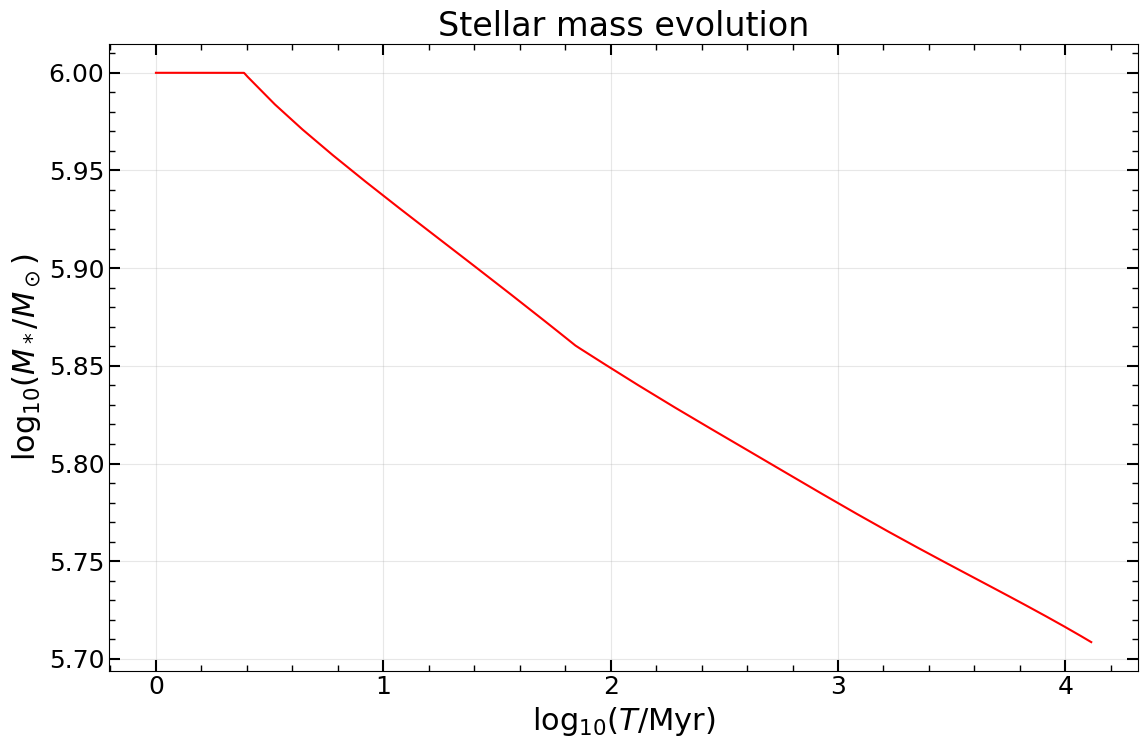

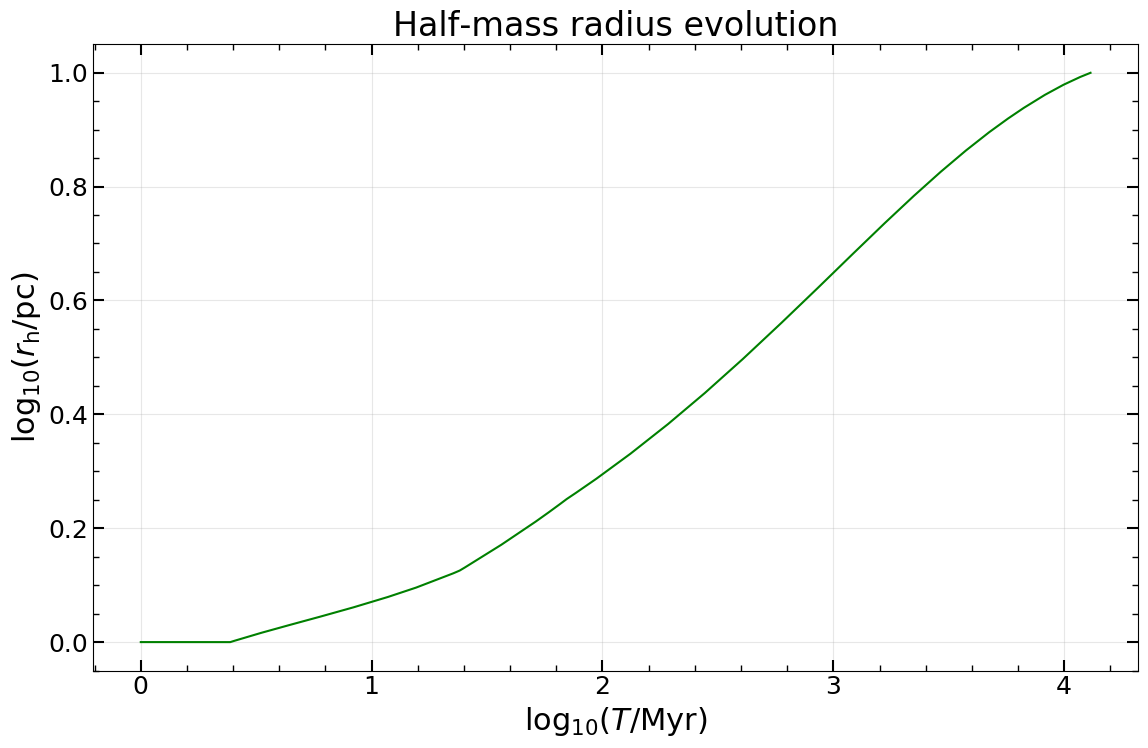

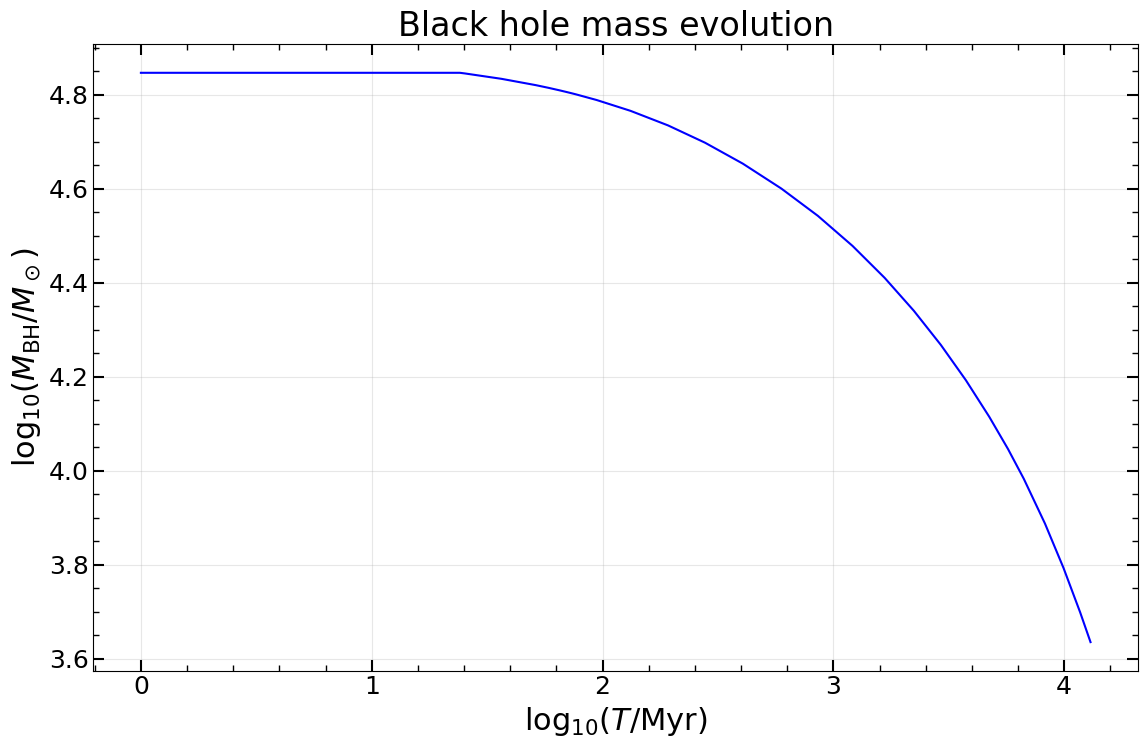

Number of mergers: 132


,t_merge,t_sim,m1,m2,m_rem,e,merger_type,rh,v_kick,v_esc,chi_f,S1,S2,a,gen,Mbh
0,8.325428e+07,2.309054e+07,79.199170,50.895331,130.094501,0.585093,ejected,1.335688,115.289703,89.322509,0.660335,0.0,0.0,0.119527,0,70225.038976
1,3.146786e+07,2.816821e+07,60.148819,41.460361,101.609179,0.987937,incluster_inspiral,1.399922,99.842766,86.517044,0.667836,0.0,0.0,0.192177,0,69344.105827
2,3.699387e+07,3.146447e+07,71.888440,39.906285,111.794725,0.912023,ejected,1.438372,142.264773,84.947391,0.640995,0.0,0.0,0.139665,0,68806.360449
3,4.137236e+07,3.621300e+07,42.589727,29.921602,72.511329,0.938217,ejected,1.490308,95.393575,82.944347,0.669667,0.0,0.0,0.060873,0,68071.363460
4,6.773605e+07,4.134394e+07,60.663273,58.628491,119.291764,0.784927,ejected,1.542732,9.813693,81.046644,0.686301,0.0,0.0,0.155613,0,67323.262031


In [11]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display, HTML

import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 24,
    'legend.fontsize': 18,
    'axes.labelsize': 22,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
})

desktop = os.path.expanduser("~/Desktop")
if desktop not in sys.path:
    sys.path.append(desktop)

from cbhbd import cbhbd

c1 = cbhbd.CBHBD(
    M0=1e6,  # initial mass [Msun]
    rh0=1.0,  # half-mass radius [pc]
    Z=0.0002,  # metallicity
    rg=8,  # galactocentric distance [kpc]
    tend=13000,  # integrate for 13 Gyr, pass time in Myr
    integration_method='RK45',  # integration method, the user can specify stopping conditions like min stellar/BH mass
    compute_mergers=True,  # skips all merger logic
    remnant_model='RemnantModelSimple',  # option for BH sampling
    seed=42,  # seed is used for mergers only
    verbose=True  # important only for mergers
)

time1 = c1.cluster.t  # [Gyr]
Mst1 = c1.cluster.Mst  # stellar mass [Msun]
rh1 = c1.cluster.rh  # half-mass radius [pc]
Mbh1 = c1.cluster.Mbh  # bh mass [Msun]

# Figure 1: Stellar mass 
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(Mst1), color='red')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(M_*/M_\odot)$')
plt.title('Stellar mass evolution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Half‑mass radius 
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(rh1), color='green')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(r_{\rm h}/\rm{pc})$')
plt.title('Half‑mass radius evolution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 3: BH mass 
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(Mbh1 + 1), color='blue')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(M_{\rm BH}/M_\odot)$')
plt.title('Black hole mass evolution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of mergers: {len(c1.mergers)}")
c1.mergers.head()

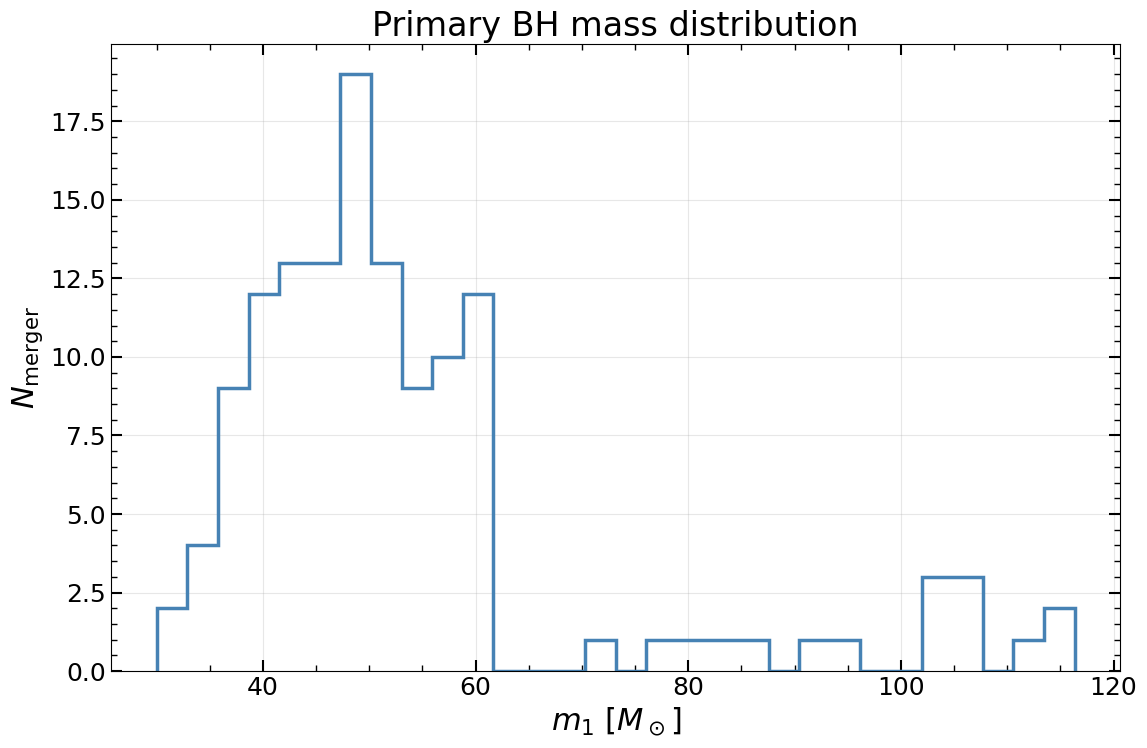

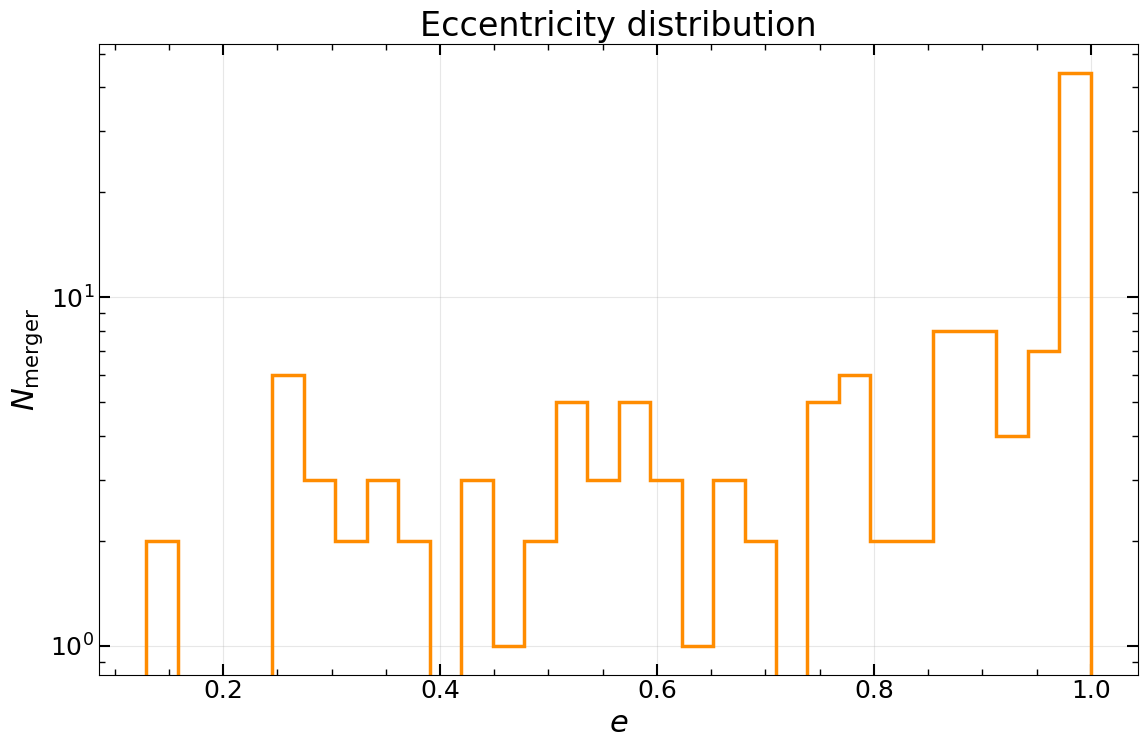

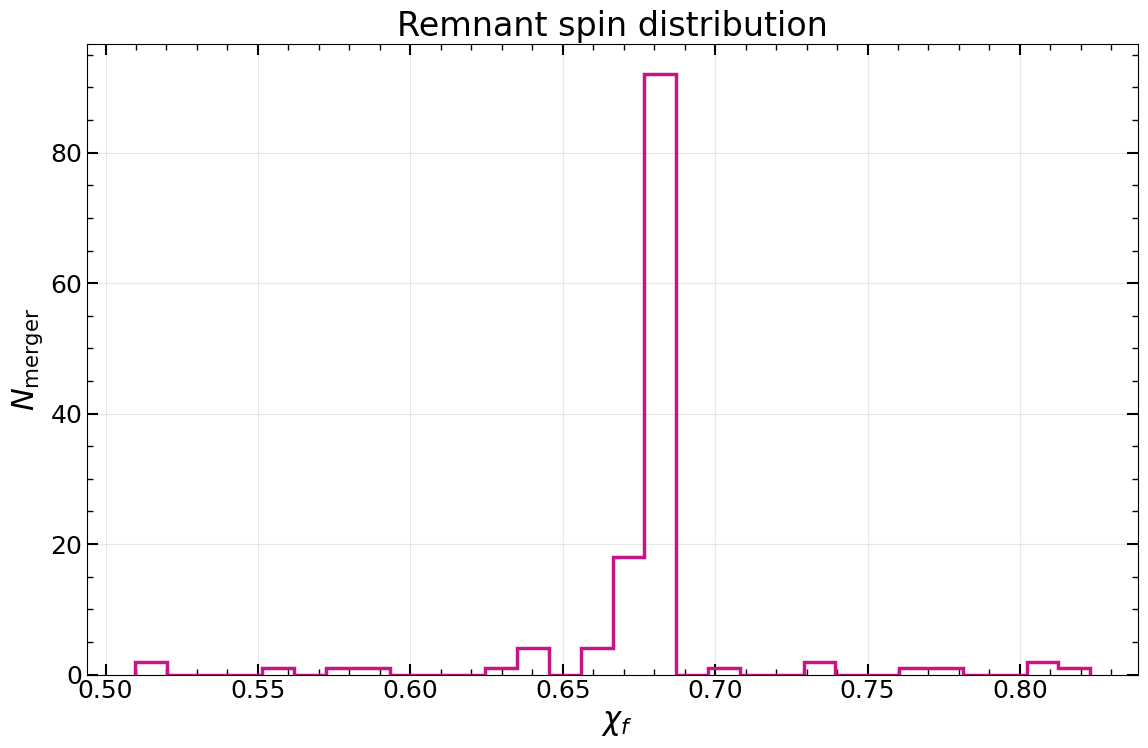

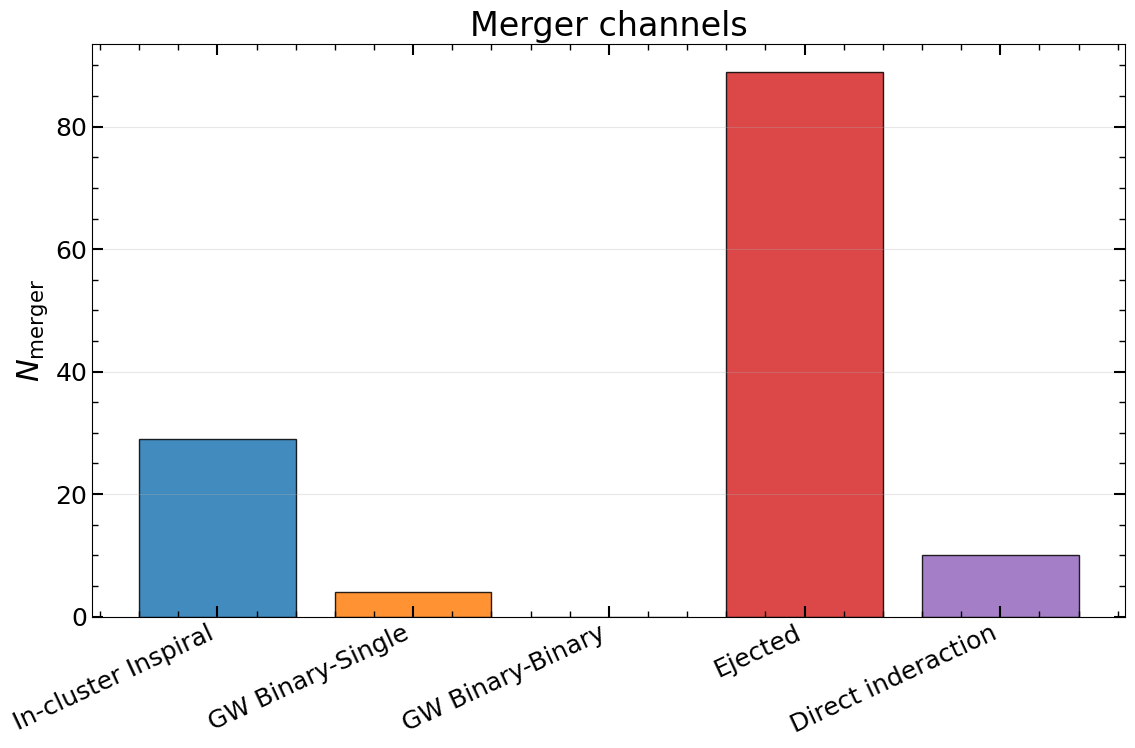

In [12]:
# ---------- Primary mass histogram  ----------
plt.figure()
plt.hist(c1.mergers['m1'], bins=30, histtype='step', color='steelblue', linewidth=2.5)
plt.xlabel('$m_1$ [$M_\\odot$]')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Primary BH mass distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Eccentricity histogram  ----------
plt.figure()
plt.hist(c1.mergers['e'], bins=30, histtype='step', color='darkorange', linewidth=2.5)
plt.xlabel('$e$')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Eccentricity distribution')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Remnant spin histogram  ----------
plt.figure()
plt.hist(c1.mergers['chi_f'], bins=30, histtype='step', color='mediumvioletred', linewidth=2.5)
plt.xlabel(' $\\chi_f$')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Remnant spin distribution')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Merger channels bar chart ----------
plt.figure()
counts = c1.mergers['merger_type'].value_counts()
outcomes = [
    'incluster_inspiral',
    'gw_capture_bs',
    'gw_capture_bb',
    'ejected',
    'gw_capture_direct'
]
labels = ['In‑cluster Inspiral', 'GW Binary-Single', 'GW Binary-Binary', 'Ejected', 'Direct inderaction']
counts_ordered = [counts.get(k, 0) for k in outcomes]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.bar(labels, counts_ordered, color=colors, edgecolor='black', alpha=0.85)
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Merger channels')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

When the cluster is evolved, the user can extract valuable macroscopic information. For example, relaxation, dispersion, tidal radius, number of particles, total energy, average masses, remaining BH fractions etc. The whole istory of these parameters is available, so the user can look into their evolution. Here we show a few examples of their final values.

In [13]:
def format_sci(x, sig=3):
    """Return a LaTeX string"""
    s = f"{x:.{sig}g}"
    if "e" not in s:
        return s
    mantissa, exp = s.split("e")
    exp = int(exp)
    if exp == 0:
        return mantissa
    return f"{mantissa} \\times 10^{{{exp}}}"


Markdown(rf"""
- $\tau_{{\rm rh}} = {format_sci(c1.cluster.trh[-1])}$ Myr  
- $\sigma = {format_sci(c1.cluster.sigma[-1])}$ km/s  
- $r_t = {format_sci(c1.cluster.rt[-1])}$ pc  
- $N = {format_sci(c1.cluster.Np[-1])}$  
- $E = {format_sci(c1.cluster.E[-1])}$ M$_\odot$ pc$^2$/Myr$^2$  
- $\langle m\rangle = {format_sci(c1.cluster.mav[-1])}$ M$_\odot$ 
- $\langle m_*\rangle = {format_sci(c1.cluster.mst[-1])}$ M$_\odot$ 
- $\langle m_{{\rm BH }}\rangle = {format_sci(c1.cluster.mbh[-1])}$ M$_\odot$ 
- $f_{{\rm BH}} = {format_sci(c1.cluster.fbh[-1])}$
""")



- $\tau_{\rm rh} = 5.73 \times 10^{3}$ Myr  
- $\sigma = 6.97$ km/s  
- $r_t = 114$ pc  
- $N = 1.6 \times 10^{6}$  
- $E = -2.39 \times 10^{7}$ M$_\odot$ pc$^2$/Myr$^2$  
- $\langle m\rangle = 0.322$ M$_\odot$ 
- $\langle m_*\rangle = 0.319$ M$_\odot$ 
- $\langle m_{\rm BH }\rangle = 19.7$ M$_\odot$ 
- $f_{\rm BH} = 0.00837$


In [14]:
n_mergers = len(c1.mergers)
med_m1 = np.median(c1.mergers['m1'])
med_ecc = np.median(c1.mergers['e'])
med_chif = np.median(c1.mergers['chi_f'])
total_mrem = c1.mergers['m_rem'].sum()

Markdown(rf"""
**Merger statistics:**  
- Number of mergers: ${n_mergers}$  
- Median primary mass: $\widetilde{{m}}_1 = {format_sci(med_m1)}$ M$_\odot$  
- Median eccentricity: $\widetilde{{e}} = {med_ecc:.3f}$  
- Median remnant spin: $\widetilde{{\chi}}_f = {med_chif:.3f}$  
- Total mass in merger remnants: ${format_sci(total_mrem)}$ M$_\odot$
""")


**Merger statistics:**  
- Number of mergers: $132$  
- Median primary mass: $\widetilde{m}_1 = 48.6$ M$_\odot$  
- Median eccentricity: $\widetilde{e} = 0.875$  
- Median remnant spin: $\widetilde{\chi}_f = 0.683$  
- Total mass in merger remnants: $1.27 \times 10^{4}$ M$_\odot$


## IMF

The default option for cbhbd is a power-law mass function which allows for several slopes and mass breaks. They can be used in order to specify both the average stellar mass initially, but also the BH population when the option ssp=True (default option). Note that the user must specify, similar to a_slopes, the parameter nbins that shows the number of bins per interval over which the IMF is separated. The default is nbins=[5,5,20]

Generating new model with
	 Mass = 1e+06 M_sun
	 Metallicity = 2.00e-04
	 Final time = 1.3e+04 Myr
	 Initial density = 1.19e+05 M_sun/pc^3
	 Seed = 42
	 Number of BHs after natal kicks: 2263
	 Averaged BH mass after kicks: 39.40
	 BH mass fraction: fbh0 = 0.0892
Generating new model with
	 Mass = 1e+06 M_sun
	 Metallicity = 2.00e-04
	 Final time = 1.3e+04 Myr
	 Initial density = 1.19e+05 M_sun/pc^3
	 Seed = 42
	 Number of BHs after natal kicks: 731
	 Averaged BH mass after kicks: 37.77
	 BH mass fraction: fbh0 = 0.0276


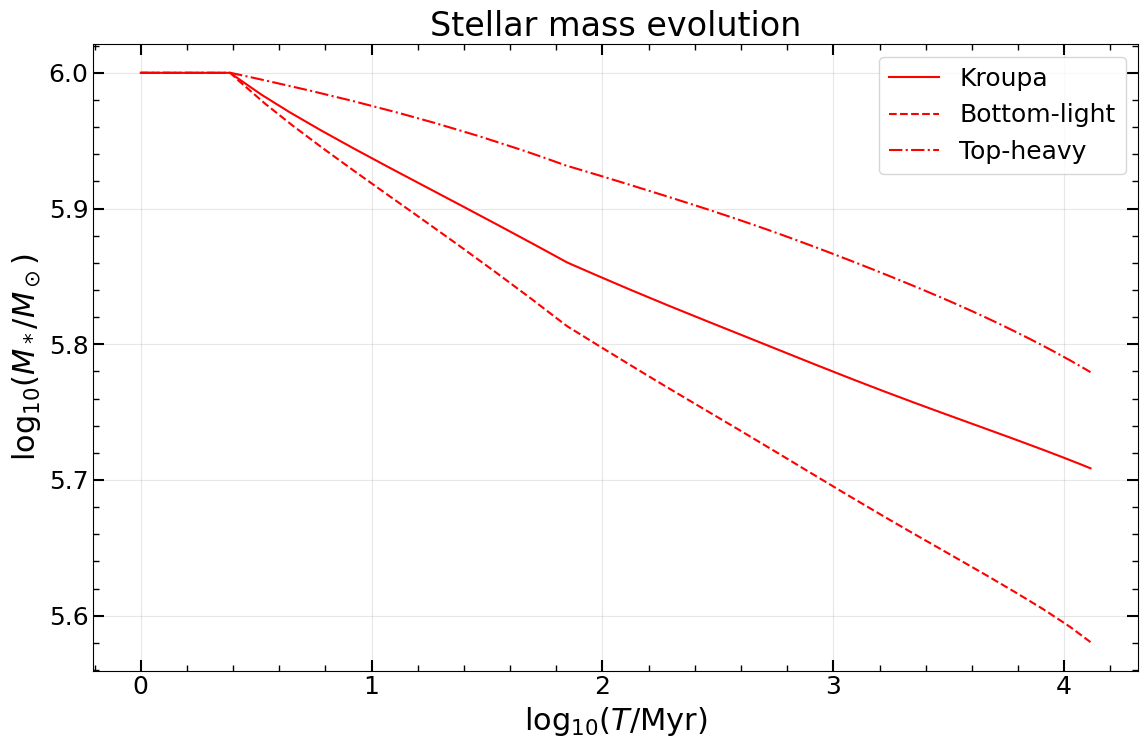

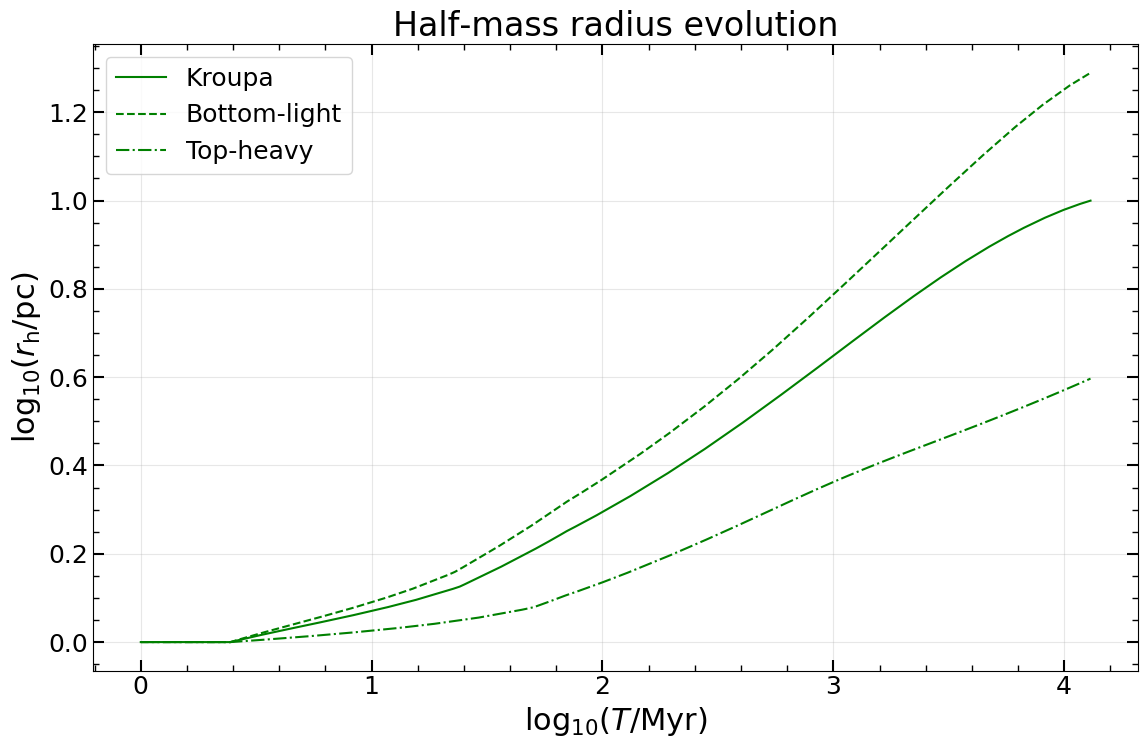

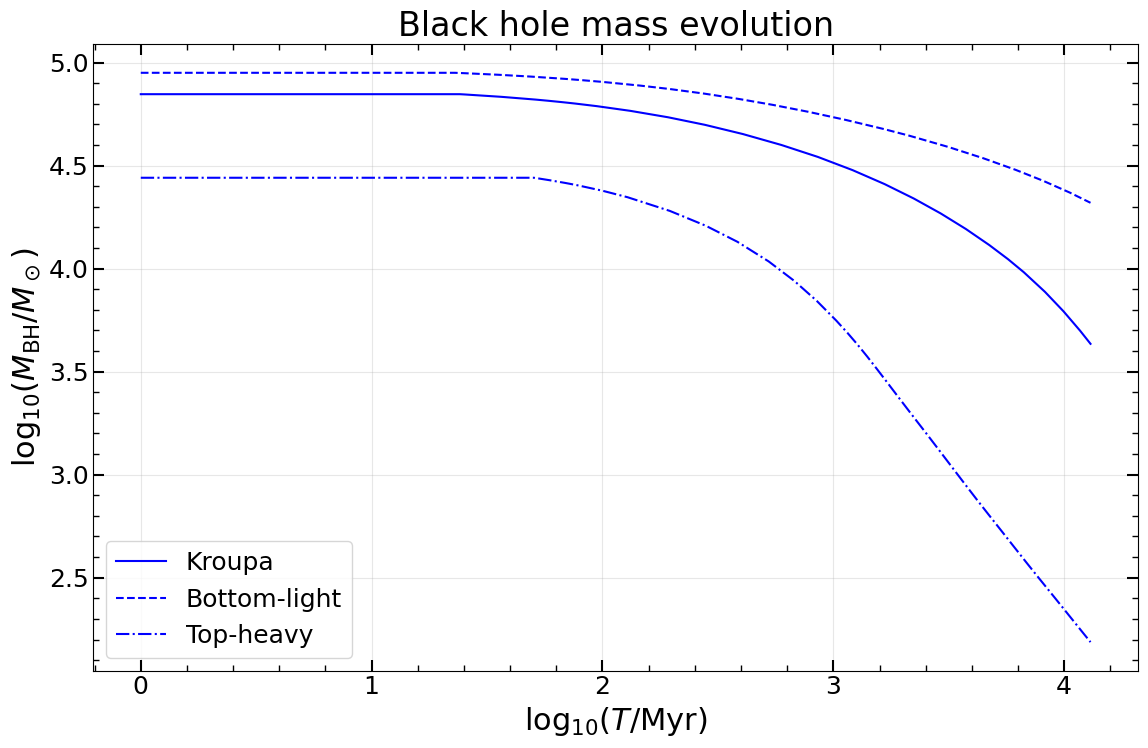


- Kroupa IMF: $m_0 = 0.586$ M$_\odot$  
- Bottom‑light IMF: $m_0 = 1.12$ M$_\odot$  
- Top‑heavy IMF: $m_0 = 0.467$ M$_\odot$  


In [17]:
c2a = cbhbd.CBHBD(
    M0=1e6,  # initial mass [Msun]
    rh0=1.0,  # half-mass radius [pc]
    Z=0.0002,  # metallicity
    rg=8,  # galactocentric distance [kpc]
    tend=13000,  # integrate for 13 Gyr, pass time in Myr
    a_slopes=[-0.3, -1.65, -2.3],  # IMF slopes
    m_breaks=[0.08, 0.5, 1, 150],  # Masses in the IMF. This is the default option
    compute_mergers=True,  # skips all merger logic
    remnant_model='RemnantModelSimple',  # option for BH sampling
    seed=42,  # seed is used for mergers only
    verbose=True  # important only for mergers
)

c2b = cbhbd.CBHBD(
    M0=1e6,  # initial mass [Msun]
    rh0=1.0,  # half-mass radius [pc]
    Z=0.0002,  # metallicity
    rg=8,  # galactocentric distance [kpc]
    tend=13000,  # integrate for 13 Gyr, pass time in Myr
    a_slopes=[-1.3, -2.3, -2.6],  # IMF slopes
    m_breaks=[0.08, 0.5, 1, 150],  # Masses in the IMF. This is the default option
    compute_mergers=True,  # skips all merger logic
    remnant_model='RemnantModelSimple',  # option for BH sampling
    seed=42,  # seed is used for mergers only
    verbose=True  # important only for mergers
)

time2a = c2a.cluster.t  # [Gyr]
Mst2a = c2a.cluster.Mst  # Stellar mass [Msun]
rh2a = c2a.cluster.rh  # Half-mass radius [pc]
Mbh2a = c2a.cluster.Mbh  # BH mass [Msun]

time2b = c2b.cluster.t  # [Gyr]
Mst2b = c2b.cluster.Mst  # Stellar mass [Msun]
rh2b = c2b.cluster.rh  # Half-mass radius [pc]
Mbh2b = c2b.cluster.Mbh  # BH mass [Msun]

# Figure 1: Stellar mass 
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(Mst1), color='red', linestyle='-', label='Kroupa')
plt.plot(np.log10(time2a * 1e3 + 1), np.log10(Mst2a), color='red', linestyle='--', label='Bottom-light')
plt.plot(np.log10(time2b * 1e3 + 1), np.log10(Mst2b), color='red', linestyle='-.', label='Top-heavy')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(M_*/M_\odot)$')
plt.title('Stellar mass evolution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Half‑mass radius
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(rh1), color='green', linestyle='-', label='Kroupa')
plt.plot(np.log10(time2a * 1e3 + 1), np.log10(rh2a), color='green', linestyle='--', label='Bottom-light')
plt.plot(np.log10(time2b * 1e3 + 1), np.log10(rh2b), color='green', linestyle='-.', label='Top-heavy')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(r_{\rm h}/\rm{pc})$')
plt.title('Half‑mass radius evolution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 3: BH mass 
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(Mbh1 + 1), color='blue', linestyle='-', label='Kroupa')
plt.plot(np.log10(time2a * 1e3 + 1), np.log10(Mbh2a + 1), color='blue', linestyle='--', label='Bottom-light')
plt.plot(np.log10(time2b * 1e3 + 1), np.log10(Mbh2b + 1), color='blue', linestyle='-.', label='Top-heavy')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(M_{\rm BH}/M_\odot)$')
plt.title('Black hole mass evolution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(HTML("<h2>The average masses initially are:</h2>"))

Markdown(rf"""
- Kroupa IMF: $m_0 = {c1.cluster.m0:.3g}$ M$_\odot$  
- Bottom‑light IMF: $m_0 = {c2a.cluster.m0:.3g}$ M$_\odot$  
- Top‑heavy IMF: $m_0 = {c2b.cluster.m0:.3g}$ M$_\odot$  
""")

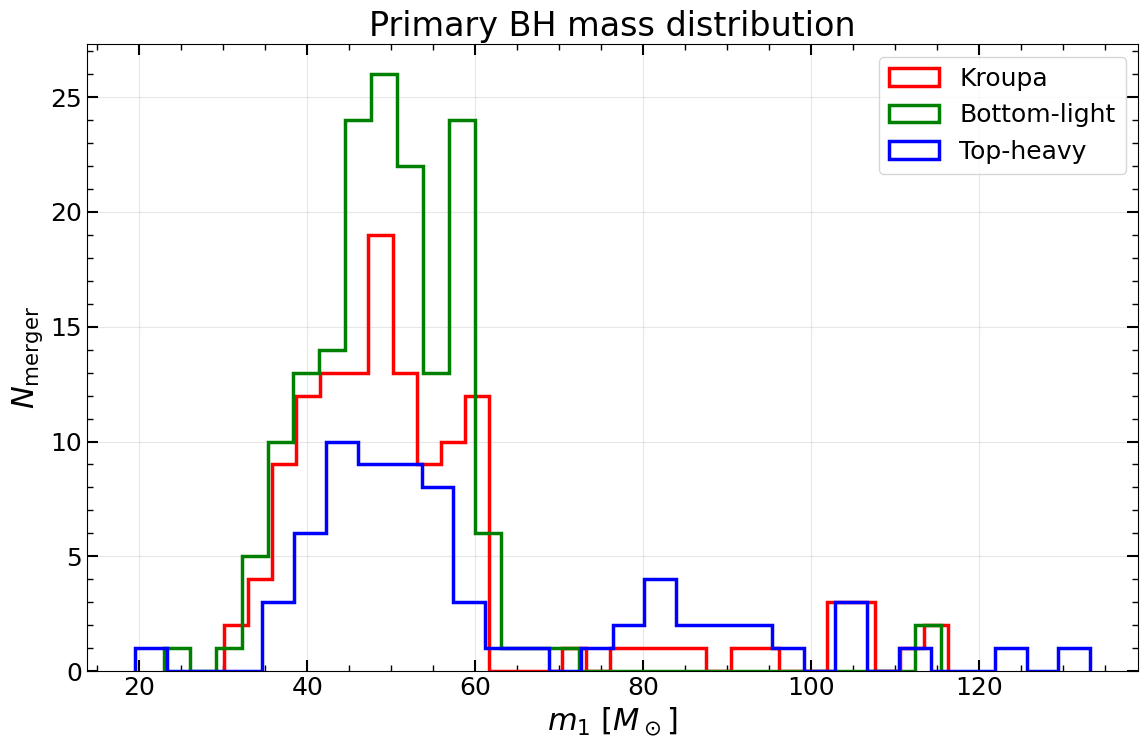

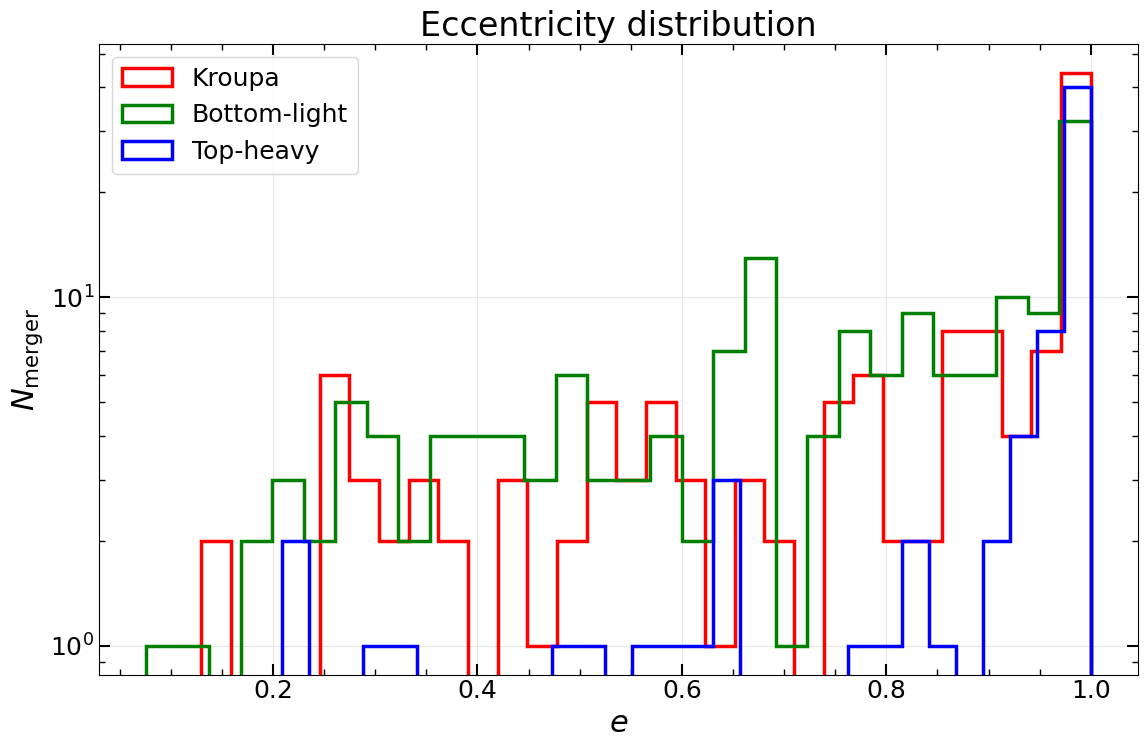

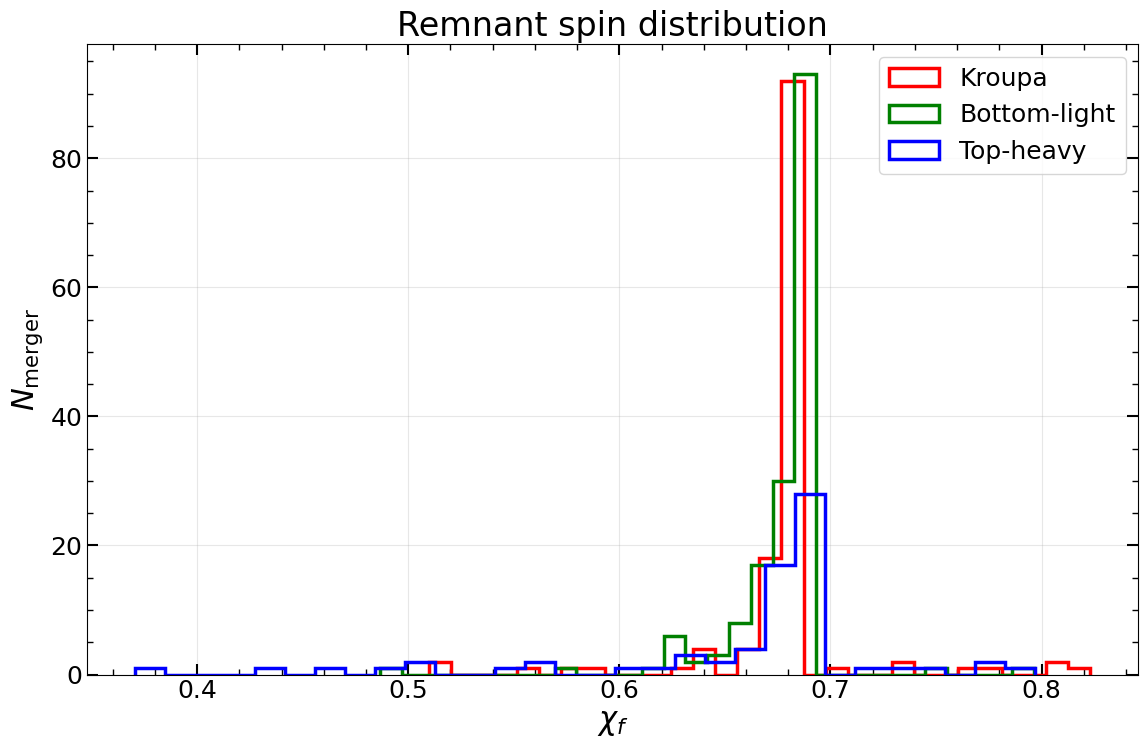

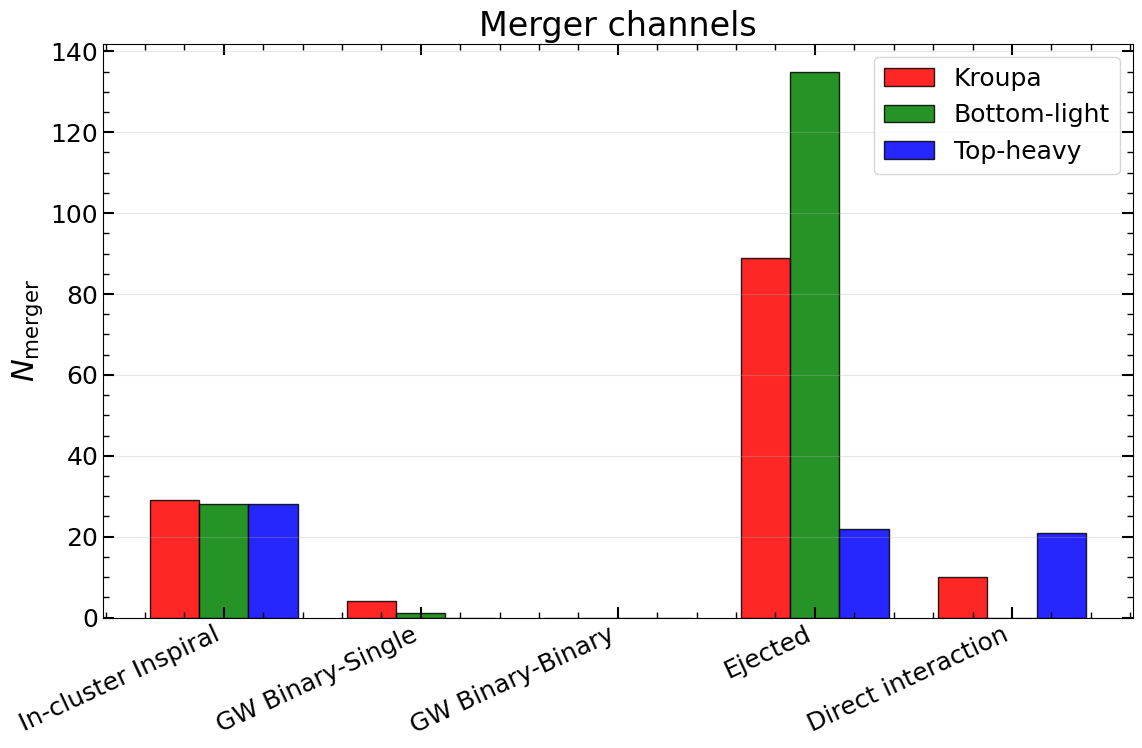

In [18]:
# ---------- 1. Primary mass histogram ----------
plt.figure()
plt.hist(c1.mergers['m1'], bins=30, histtype='step', color='red', linewidth=2.5, label='Kroupa')
plt.hist(c2a.mergers['m1'], bins=30, histtype='step', color='green', linewidth=2.5, label='Bottom‑light')
plt.hist(c2b.mergers['m1'], bins=30, histtype='step', color='blue', linewidth=2.5, label='Top‑heavy')
plt.xlabel('$m_1$ [$M_\\odot$]')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Primary BH mass distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 2. Eccentricity histogram ----------
plt.figure()
plt.hist(c1.mergers['e'], bins=30, histtype='step', color='red', linewidth=2.5, label='Kroupa')
plt.hist(c2a.mergers['e'], bins=30, histtype='step', color='green', linewidth=2.5, label='Bottom‑light')
plt.hist(c2b.mergers['e'], bins=30, histtype='step', color='blue', linewidth=2.5, label='Top‑heavy')
plt.xlabel('$e$')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Eccentricity distribution')
plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 3. Remnant spin histogram  ----------
plt.figure()
plt.hist(c1.mergers['chi_f'], bins=30, histtype='step', color='red', linewidth=2.5, label='Kroupa')
plt.hist(c2a.mergers['chi_f'], bins=30, histtype='step', color='green', linewidth=2.5, label='Bottom‑light')
plt.hist(c2b.mergers['chi_f'], bins=30, histtype='step', color='blue', linewidth=2.5, label='Top‑heavy')
plt.xlabel('$\\chi_f$')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Remnant spin distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 4. Merger channels (grouped bar chart) ----------
outcomes = [
    'incluster_inspiral',
    'gw_capture_bs',
    'gw_capture_bb',
    'ejected',
    'gw_capture_direct'
]
labels = ['In‑cluster Inspiral', 'GW Binary‑Single', 'GW Binary‑Binary', 'Ejected', 'Direct interaction']
counts_kroupa = [c1.mergers['merger_type'].value_counts().get(k, 0) for k in outcomes]
counts_blight = [c2a.mergers['merger_type'].value_counts().get(k, 0) for k in outcomes]
counts_theavy = [c2b.mergers['merger_type'].value_counts().get(k, 0) for k in outcomes]

x = np.arange(len(labels))
width = 0.25

plt.figure()
plt.bar(x - width, counts_kroupa, width, color='red', edgecolor='black', alpha=0.85, label='Kroupa')
plt.bar(x, counts_blight, width, color='green', edgecolor='black', alpha=0.85, label='Bottom‑light')
plt.bar(x + width, counts_theavy, width, color='blue', edgecolor='black', alpha=0.85, label='Top‑heavy')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Merger channels')
plt.xticks(x, labels, rotation=25, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## IFMR

When the ssptools are activated, the user has the option of selecting different ifmr relations. This affects only the production of BHs and not how the cluster evolves, meaning that the fitted parameters are expected to be the same. 

Generating new model with
	 Mass = 1e+06 M_sun
	 Metallicity = 2.00e-04
	 Final time = 1.3e+04 Myr
	 Initial density = 1.19e+05 M_sun/pc^3
	 Seed = 42
	 Number of BHs after natal kicks: 2124
	 Averaged BH mass after kicks: 22.76
	 BH mass fraction: fbh0 = 0.0483
Generating new model with
	 Mass = 1e+06 M_sun
	 Metallicity = 2.00e-04
	 Final time = 1.3e+04 Myr
	 Initial density = 1.19e+05 M_sun/pc^3
	 Seed = 42
	 Number of BHs after natal kicks: 2140
	 Averaged BH mass after kicks: 24.37
	 BH mass fraction: fbh0 = 0.0522
Generating new model with
	 Mass = 1e+06 M_sun
	 Metallicity = 2.00e-04
	 Final time = 1.3e+04 Myr
	 Initial density = 1.19e+05 M_sun/pc^3
	 Seed = 42
	 Number of BHs after natal kicks: 2353
	 Averaged BH mass after kicks: 23.99
	 BH mass fraction: fbh0 = 0.0565


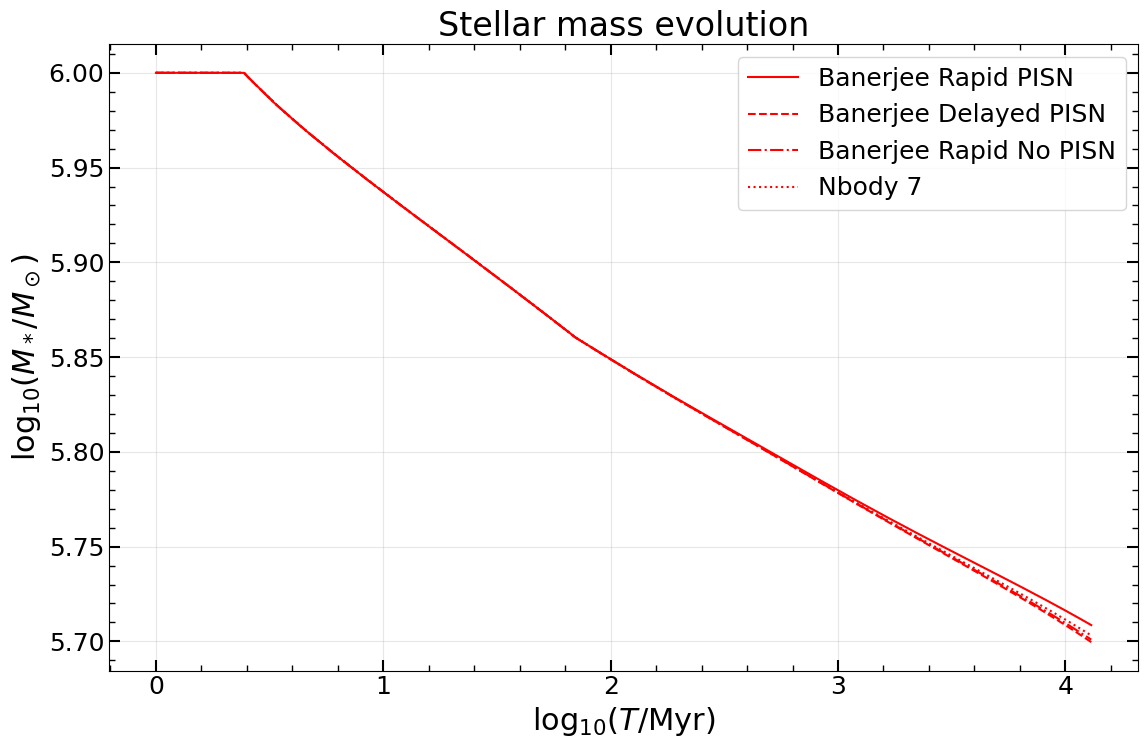

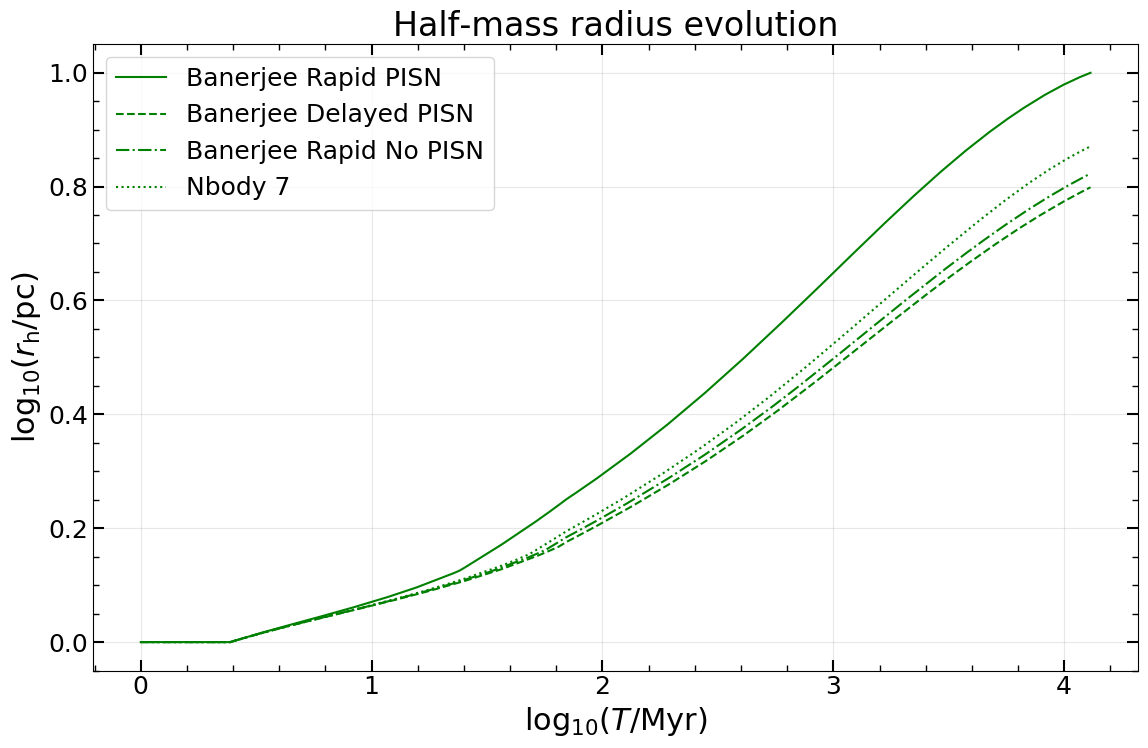

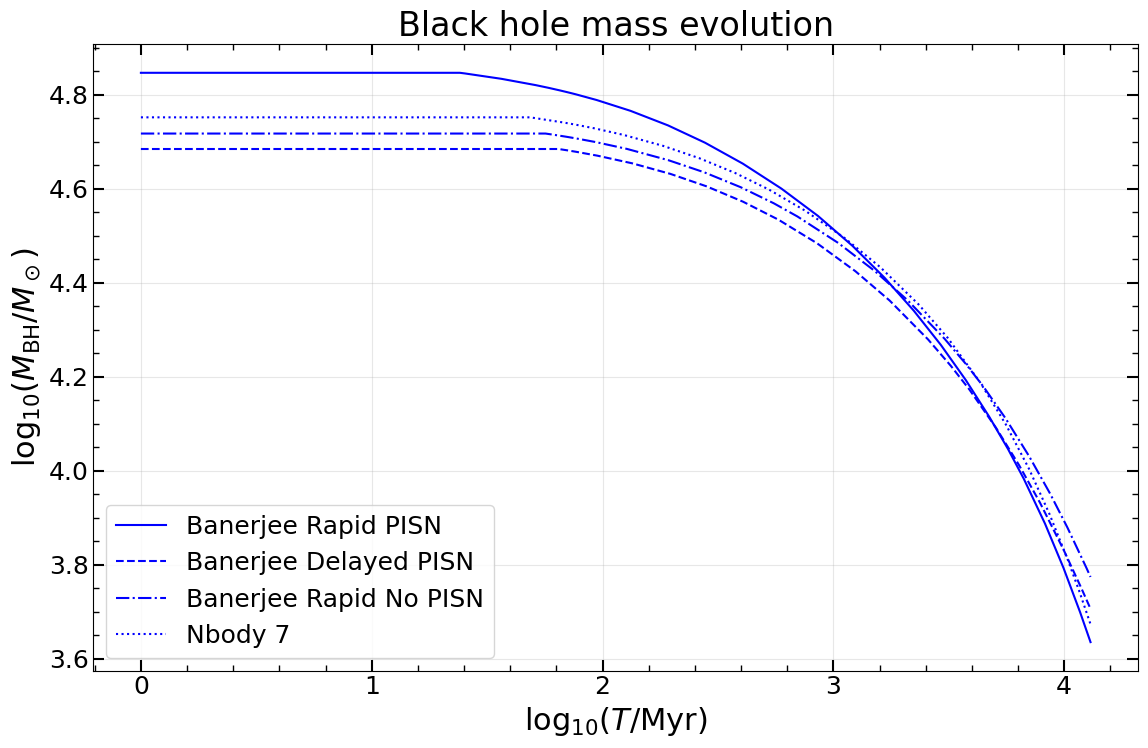


- **Banerjee Rapid PISN**: $t_{\rm cc} = 23.1$ Myr  
- **Banerjee Delayed PISN**: $t_{\rm cc} = 63.5$ Myr  
- **Banerjee Rapid No PISN**: $t_{\rm cc} = 55.6$ Myr  
- **Nbody 7**: $t_{\rm cc} = 47.4$ Myr  


In [21]:
c3a = cbhbd.CBHBD(
    M0=1e6,  # initial mass [Msun]
    rh0=1.0,  # half-mass radius [pc]
    Z=0.0002,  # metallicity, now passes but is unused
    rg=8,  # galactocentric distance [kpc]
    tend=13000,  # integrate for 13 Gyr, pass time in Myr
    ifmr='ba20-delayed-ppsn',
    # ifmr option, default is ba20-rapid-ppsn, all documentation is available in ssptools, along with kicks
    compute_mergers=True,  # skips all merger logic
    remnant_model='RemnantModelSimple',  # option for BH sampling
    seed=42,  # seed is used for mergers only
    verbose=True  # important only for mergers
)

c3b = cbhbd.CBHBD(
    M0=1e6,  # initial mass [Msun]
    rh0=1.0,  # half-mass radius [pc]
    Z=0.0002,  # metallicity
    rg=8,  # galactocentric distance [kpc]
    tend=13000,  # integrate for 13 Gyr, pass time in Myr
    ifmr='ba20-delayed',  # ifmr option, ignores PISN
    compute_mergers=True,  # skips all merger logic
    remnant_model='RemnantModelSimple',  # option for BH sampling
    seed=42,  # seed is used for mergers only
    verbose=True  # important only for mergers
)

c3c = cbhbd.CBHBD(
    M0=1e6,  # initial mass [Msun]
    rh0=1.0,  # half-mass radius [pc]
    Z=0.0002,  # metallicity
    rg=8,  # galactocentric distance [kpc]
    tend=13000,  # integrate for 13 Gyr, pass time in Myr
    ifmr='nbody7-rapid',  # ifmr option, ignores PISN
    compute_mergers=True,  # skips all merger logic
    remnant_model='RemnantModelSimple',  # option for BH sampling
    seed=42,  # seed is used for mergers only
    verbose=True  # important only for mergers
)

time3a = c3a.cluster.t  # [Gyr]
Mst3a = c3a.cluster.Mst  # Stellar mass [Msun]
rh3a = c3a.cluster.rh  # Half-mass radius [pc]
Mbh3a = c3a.cluster.Mbh  # BH mass [Msun]

time3b = c3b.cluster.t  # [Gyr]
Mst3b = c3b.cluster.Mst  # Stellar mass [Msun]
rh3b = c3b.cluster.rh  # Half-mass radius [pc]
Mbh3b = c3b.cluster.Mbh  # BH mass [Msun]

time3c = c3c.cluster.t  # [Gyr]
Mst3c = c3c.cluster.Mst  # Stellar mass [Msun]
rh3c = c3c.cluster.rh  # Half-mass radius [pc]
Mbh3c = c3c.cluster.Mbh  # BH mass [Msun]

# Figure 1: Stellar mass
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(Mst1), color='red', linestyle='-', label='Banerjee Rapid PISN')
plt.plot(np.log10(time3a * 1e3 + 1), np.log10(Mst3a), color='red', linestyle='--', label='Banerjee Delayed PISN')
plt.plot(np.log10(time3b * 1e3 + 1), np.log10(Mst3b), color='red', linestyle='-.', label='Banerjee Rapid No PISN')
plt.plot(np.log10(time3c * 1e3 + 1), np.log10(Mst3c), color='red', linestyle=':', label='Nbody 7')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(M_*/M_\odot)$')
plt.title('Stellar mass evolution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Half‑mass radius
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(rh1), color='green', linestyle='-', label='Banerjee Rapid PISN')
plt.plot(np.log10(time3a * 1e3 + 1), np.log10(rh3a), color='green', linestyle='--', label='Banerjee Delayed PISN')
plt.plot(np.log10(time3b * 1e3 + 1), np.log10(rh3b), color='green', linestyle='-.', label='Banerjee Rapid No PISN')
plt.plot(np.log10(time3c * 1e3 + 1), np.log10(rh3c), color='green', linestyle=':', label='Nbody 7')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(r_{\rm h}/\rm{pc})$')
plt.title('Half‑mass radius evolution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 3: BH mass 
plt.figure()
plt.plot(np.log10(time1 * 1e3 + 1), np.log10(Mbh1 + 1), color='blue', linestyle='-', label='Banerjee Rapid PISN')
plt.plot(np.log10(time3a * 1e3 + 1), np.log10(Mbh3a + 1), color='blue', linestyle='--', label='Banerjee Delayed PISN')
plt.plot(np.log10(time3b * 1e3 + 1), np.log10(Mbh3b + 1), color='blue', linestyle='-.', label='Banerjee Rapid No PISN')
plt.plot(np.log10(time3c * 1e3 + 1), np.log10(Mbh3c + 1), color='blue', linestyle=':', label='Nbody 7')
plt.xlabel(r'$\mathrm{log}_{10}(T/\mathrm{Myr})$')
plt.ylabel(r'$\mathrm{log}_{10}(M_{\rm BH}/M_\odot)$')
plt.title('Black hole mass evolution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(HTML("<h2>The core collapse times are:</h2>"))

Markdown(rf"""
- **Banerjee Rapid PISN**: $t_{{\rm cc}} = {format_sci(c1.cluster.tcc)}$ Myr  
- **Banerjee Delayed PISN**: $t_{{\rm cc}} = {format_sci(c3a.cluster.tcc)}$ Myr  
- **Banerjee Rapid No PISN**: $t_{{\rm cc}} = {format_sci(c3b.cluster.tcc)}$ Myr  
- **Nbody 7**: $t_{{\rm cc}} = {format_sci(c3c.cluster.tcc)}$ Myr  
""")


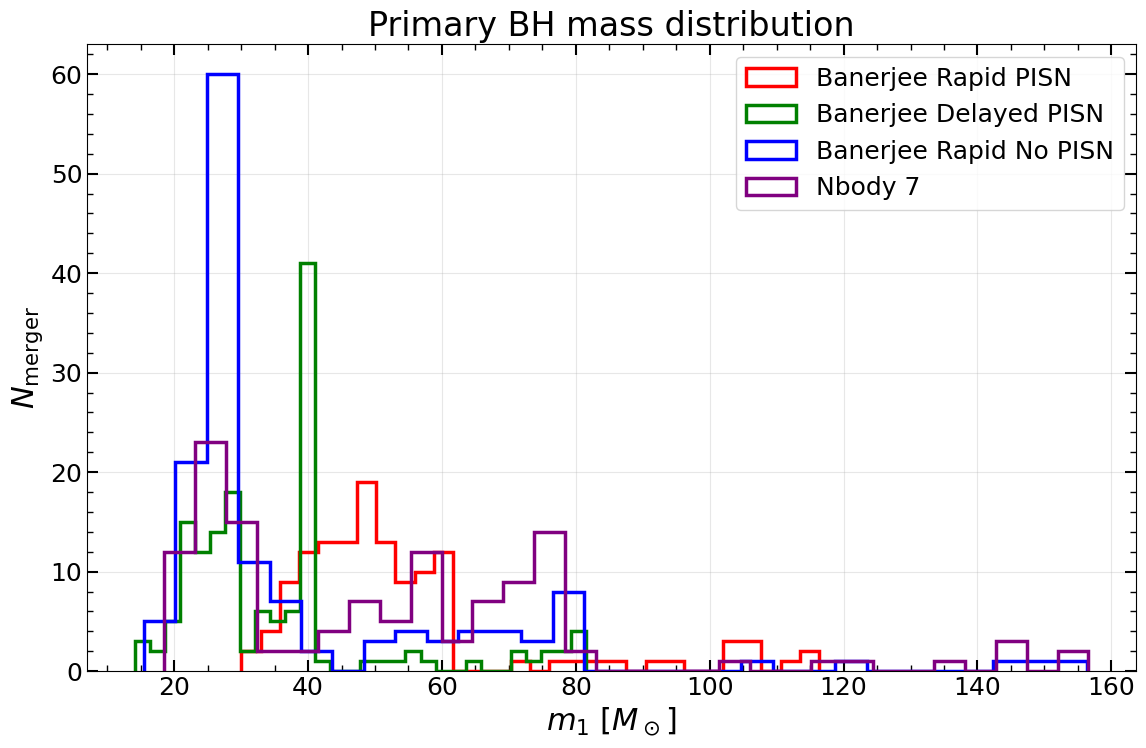

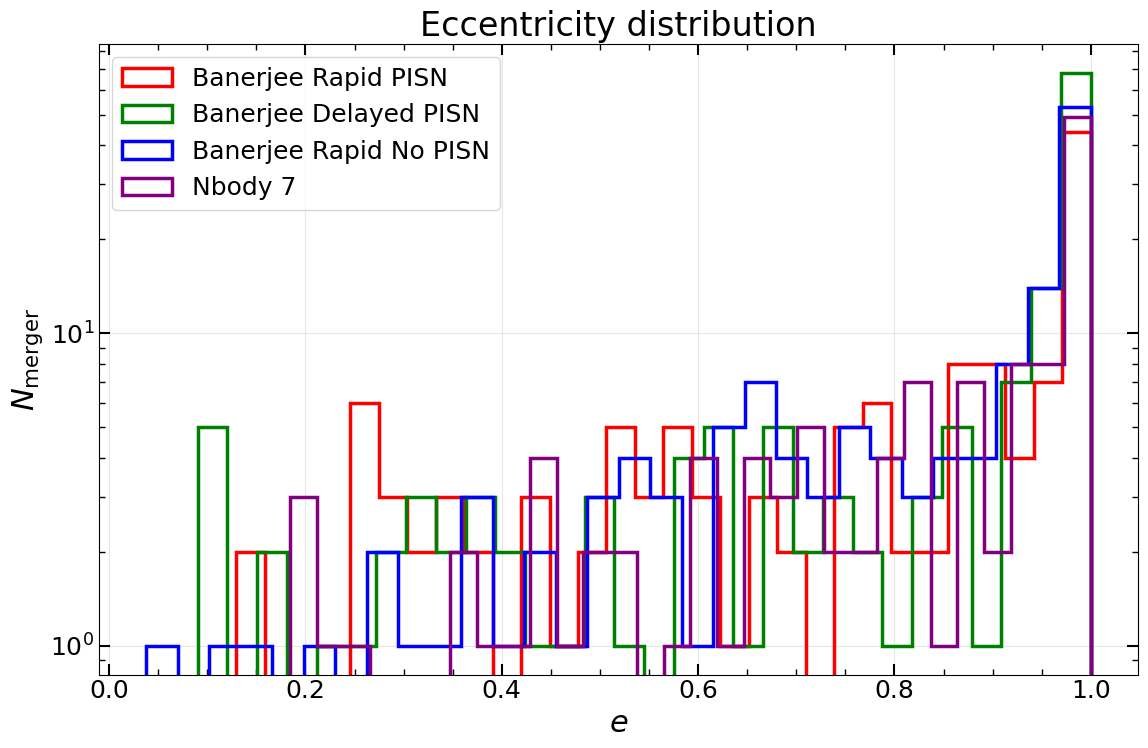

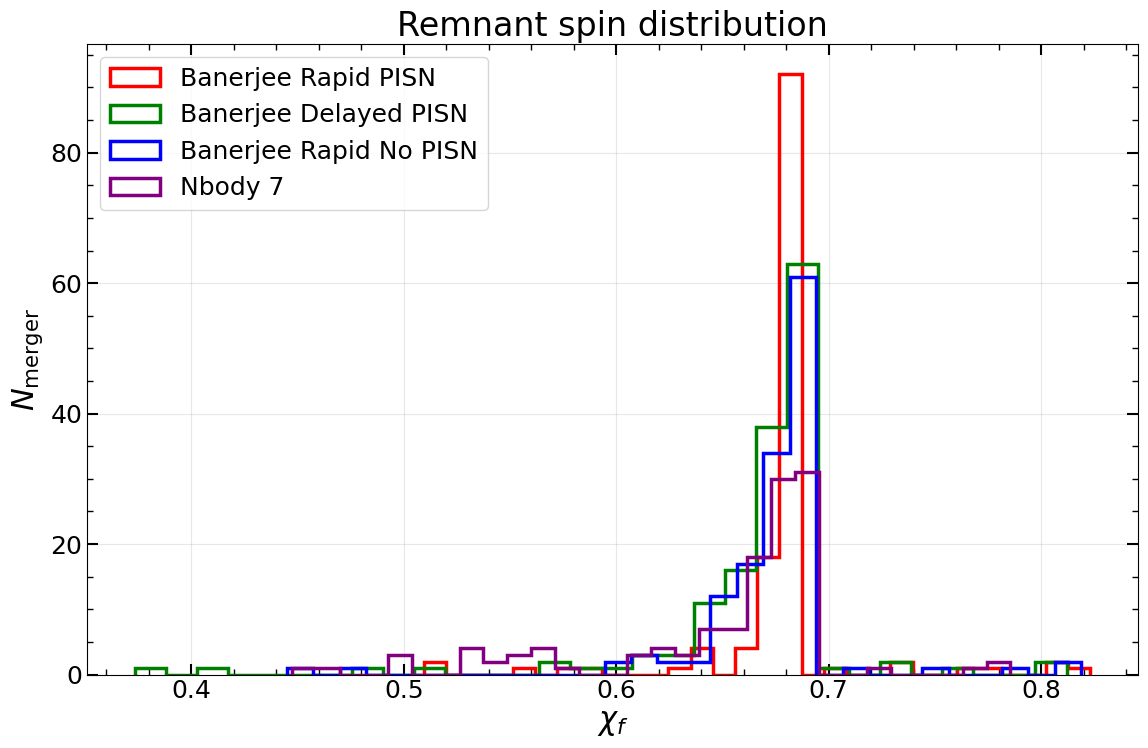

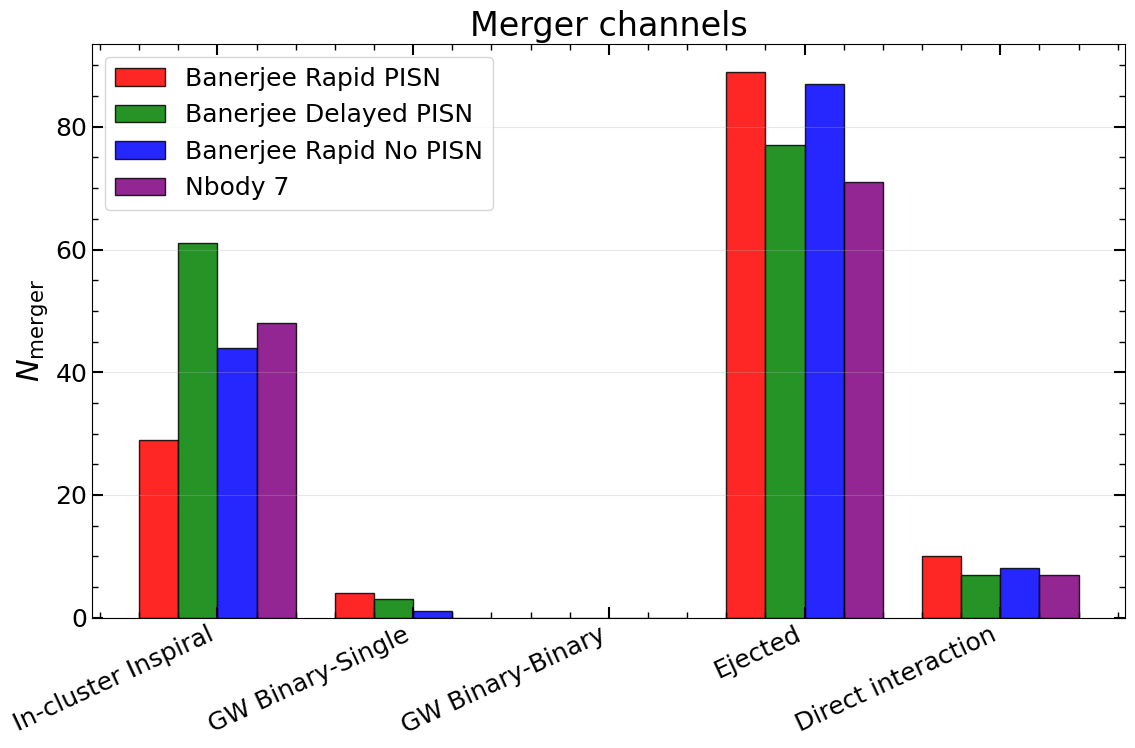

In [22]:
# ---------- 1. Primary mass histogram ----------
plt.figure()
plt.hist(c1.mergers['m1'], bins=30, histtype='step', color='red', linewidth=2.5, label='Banerjee Rapid PISN')
plt.hist(c3a.mergers['m1'], bins=30, histtype='step', color='green', linewidth=2.5, label='Banerjee Delayed PISN')
plt.hist(c3b.mergers['m1'], bins=30, histtype='step', color='blue', linewidth=2.5, label='Banerjee Rapid No PISN')
plt.hist(c3c.mergers['m1'], bins=30, histtype='step', color='purple', linewidth=2.5, label='Nbody 7')
plt.xlabel('$m_1$ [$M_\\odot$]')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Primary BH mass distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 2. Eccentricity histogram  ----------
plt.figure()
plt.hist(c1.mergers['e'], bins=30, histtype='step', color='red', linewidth=2.5, label='Banerjee Rapid PISN')
plt.hist(c3a.mergers['e'], bins=30, histtype='step', color='green', linewidth=2.5, label='Banerjee Delayed PISN')
plt.hist(c3b.mergers['e'], bins=30, histtype='step', color='blue', linewidth=2.5, label='Banerjee Rapid No PISN')
plt.hist(c3c.mergers['e'], bins=30, histtype='step', color='purple', linewidth=2.5, label='Nbody 7')
plt.xlabel('$e$')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Eccentricity distribution')
plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 3. Remnant spin histogram ----------
plt.figure()
plt.hist(c1.mergers['chi_f'], bins=30, histtype='step', color='red', linewidth=2.5, label='Banerjee Rapid PISN')
plt.hist(c3a.mergers['chi_f'], bins=30, histtype='step', color='green', linewidth=2.5, label='Banerjee Delayed PISN')
plt.hist(c3b.mergers['chi_f'], bins=30, histtype='step', color='blue', linewidth=2.5, label='Banerjee Rapid No PISN')
plt.hist(c3c.mergers['chi_f'], bins=30, histtype='step', color='purple', linewidth=2.5, label='Nbody 7')
plt.xlabel('$\\chi_f$')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Remnant spin distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 4. Merger channels  ----------
outcomes = [
    'incluster_inspiral',
    'gw_capture_bs',
    'gw_capture_bb',
    'ejected',
    'gw_capture_direct'
]
labels = ['In‑cluster Inspiral', 'GW Binary‑Single', 'GW Binary‑Binary', 'Ejected', 'Direct interaction']
counts_c1 = [c1.mergers['merger_type'].value_counts().get(k, 0) for k in outcomes]
counts_c3a = [c3a.mergers['merger_type'].value_counts().get(k, 0) for k in outcomes]
counts_c3b = [c3b.mergers['merger_type'].value_counts().get(k, 0) for k in outcomes]
counts_c3c = [c3c.mergers['merger_type'].value_counts().get(k, 0) for k in outcomes]

x = np.arange(len(labels))
width = 0.2

plt.figure()
plt.bar(x - 1.5 * width, counts_c1, width, color='red', edgecolor='black', alpha=0.85, label='Banerjee Rapid PISN')
plt.bar(x - 0.5 * width, counts_c3a, width, color='green', edgecolor='black', alpha=0.85, label='Banerjee Delayed PISN')
plt.bar(x + 0.5 * width, counts_c3b, width, color='blue', edgecolor='black', alpha=0.85, label='Banerjee Rapid No PISN')
plt.bar(x + 1.5 * width, counts_c3c, width, color='purple', edgecolor='black', alpha=0.85, label='Nbody 7')
plt.ylabel(r'$N_{\rm merger}$')
plt.title('Merger channels')
plt.xticks(x, labels, rotation=25, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

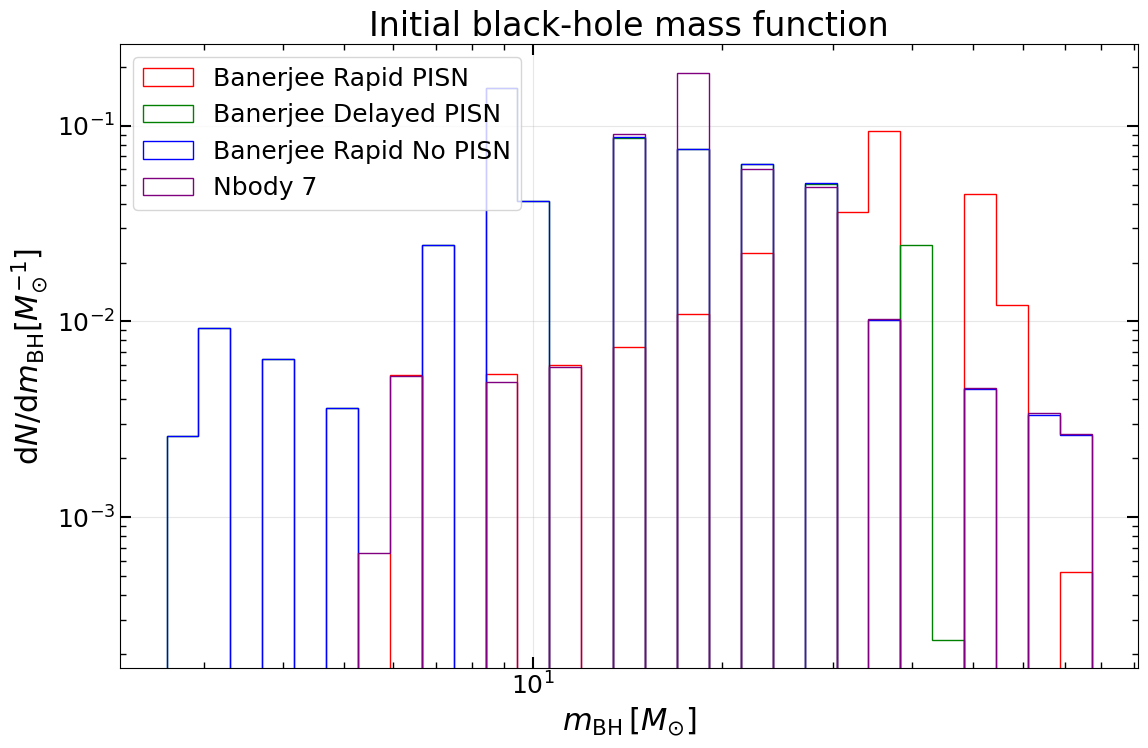


### Black‑hole mass ranges 

| IFMR model | Minimum BH mass (M☉) | Maximum BH mass (M☉) |
|------------|---------------------|---------------------|
| Banerjee Rapid PISN | 6.65 | 77.2 |
| Banerjee Delayed PISN | 2.62 | 43.1 |
| Banerjee Rapid No PISN | 2.62 | 76.7 |
| Nbody 7 | 5.64 | 76.7 |


In [23]:
def get_initial_bh_masses(ibh):
    idx = np.argsort(ibh.m)[::-1]
    masses_sorted = ibh.m[idx]
    counts_sorted = ibh.N[idx].astype(int)

    cum_counts = np.cumsum(counts_sorted)

    last_idx = np.searchsorted(cum_counts, ibh.Ntot, side='right')

    bh_masses = masses_sorted[:last_idx + 1]
    bh_counts = counts_sorted[:last_idx + 1]

    return np.repeat(bh_masses, bh_counts)


models = [
    ('Banerjee Rapid PISN', c1, 'red', '-'),
    ('Banerjee Delayed PISN', c3a, 'green', '-'),
    ('Banerjee Rapid No PISN', c3b, 'blue', '-'),
    ('Nbody 7', c3c, 'purple', '-'),
]

all_masses = []
for label, sim, color, ls in models:
    bh_masses = get_initial_bh_masses(sim.cluster.ibh)
    if len(bh_masses) > 0:
        all_masses.extend(bh_masses)
    else:
        print(f"Warning: No BHs for {label}")

if all_masses:
    min_mass = np.min(all_masses)
    max_mass = np.max(all_masses)

    bins = np.logspace(np.log10(min_mass), np.log10(max_mass), 30)
else:
    bins = 30

for label, sim, color, ls in models:
    bh_masses = get_initial_bh_masses(sim.cluster.ibh)
    if len(bh_masses) == 0:
        continue
    plt.hist(bh_masses, bins=bins, histtype='step', density=True,
             color=color, linestyle=ls, label=label)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$m_{\rm BH} \, [M_{\odot}]$')
plt.ylabel(r'$\mathrm{d}N/\mathrm{d}m_{\rm BH} [M_{\odot}^{-1}]$')
plt.title('Initial black‑hole mass function')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

md_text = "\n### Black‑hole mass ranges \n\n"
md_text += "| IFMR model | Minimum BH mass (M☉) | Maximum BH mass (M☉) |\n"
md_text += "|------------|---------------------|---------------------|\n"

for label, sim, _, _ in models:
    bh_masses = get_initial_bh_masses(sim.cluster.ibh)
    if len(bh_masses) > 0:
        min_bh = np.min(bh_masses)
        max_bh = np.max(bh_masses)
        md_text += f"| {label} | {format_sci(min_bh)} | {format_sci(max_bh)} |\n"
    else:
        md_text += f"| {label} | (no BHs) | (no BHs) |\n"

display(Markdown(md_text))